In [1]:
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from lzn.universal import *

# draw heatmap of 5ab, 8ab methods own energies together

In [2]:
general_save = to_path("~/organized/901_data")
df_all = pd.read_csv(general_save / "chen1-64_allmethods_r.csv")

In [3]:
df_all

,Unnamed: 0,ref_eV,matpes_pbe,omat24,omol25_low,mpa,matpes_r2scan,pbe0_def2svp,pbe0_def2tzvp,pbe_def2svp,pbe_def2tzvp
0,1a,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,5a,-4.026534,-3.909440,-3.918639,-4.299219,-3.973055,-4.321299,-4.512489,-4.331947,-4.281816,-4.023739
2,5b,-4.024956,-3.903593,-3.921683,-4.336719,-3.967011,-4.334269,-4.571154,-4.353400,-4.323466,-4.036192
3,8a,-4.621538,-4.449787,-4.461456,-4.964844,-4.502728,-4.951170,-5.223620,-4.992960,-4.942982,-4.633137
4,8b,-4.607548,-4.432922,-4.448328,-4.972656,-4.492523,-4.937876,-5.238399,-4.993457,-4.956060,-4.632757
5,12a,-4.924655,-4.739760,-4.750633,-5.324219,-4.787299,-5.287616,-5.583910,-5.342232,NaN,NaN
6,12b,-4.831207,-4.693429,-4.713351,-5.342448,-4.775003,-5.277019,-5.530746,NaN,NaN,NaN
7,12c,-4.796835,-4.659173,-4.669095,-5.287760,-4.730518,-5.230607,-5.468361,NaN,NaN,NaN
8,12d,-4.616196,-4.425592,-4.432409,-4.902344,-4.465445,-4.893522,-5.187037,NaN,NaN,NaN
9,40a,-5.394503,-5.159000,-5.165060,-5.849219,-5.213998,-5.803492,NaN,NaN,NaN,NaN


In [13]:
# dE(b-a)
df_8dE = pd.DataFrame(df_all.iloc[4,1:] - df_all.iloc[3,1:])
df_5dE = pd.DataFrame(df_all.iloc[2,1:] - df_all.iloc[1,1:])

df_l = [df_8dE, df_5dE]
for df in df_l:
    df.columns = ["dEab eV"]
    df.rename(index={"ref_eV":"article"}, inplace=True)

df_8dE

,dEab eV
article,0.01399
matpes_pbe,0.016865
omat24,0.013128
omol25_low,-0.007812
mpa,0.010204
matpes_r2scan,0.013294
pbe0_def2svp,-0.01478
pbe0_def2tzvp,-0.000498
pbe_def2svp,-0.013078
pbe_def2tzvp,0.000379


In [31]:
df_58dE = pd.concat(df_l, axis=1)
df_58dE.columns = ["dE5 / eV", "dE8 / eV"]
df_58dE.to_csv(general_save / "dE_58ab_self_val.csv")
df_58dE


,dE5 / eV,dE8 / eV
article,0.01399,0.001578
matpes_pbe,0.016865,0.005847
omat24,0.013128,-0.003044
omol25_low,-0.007812,-0.0375
mpa,0.010204,0.006044
matpes_r2scan,0.013294,-0.01297
pbe0_def2svp,-0.01478,-0.058665
pbe0_def2tzvp,-0.000498,-0.021454
pbe_def2svp,-0.013078,-0.04165
pbe_def2tzvp,0.000379,-0.012453


In [15]:
# Matrix construction
def construct_matrix(df):
    name_list = df.index.tolist()
    df_E_matrix = pd.DataFrame(index=name_list, columns=name_list)

    for i in range(len(name_list)):
        for ii in range(i,len(name_list)):
            name_i, name_ii = name_list[i], name_list[ii]
            dE_i = df.loc[name_i, 'dEab eV']
            dE_ii = df.loc[name_ii, 'dEab eV']
            d_dE = dE_ii - dE_i
            df_E_matrix.loc[name_i, name_ii] = d_dE

    return df_E_matrix

# Symmetrize: flip top-right to down-left
def symmetrize_matrix(df):
    size_df = len(df)
    for i in range(size_df):
        for ii in range(i,size_df):
            df.iloc[ii, i] = df.iloc[i, ii]
    return df



In [16]:
df_E_matrix_l = []
df_n = [8,5]

for df in df_l:
    df_E_matrix = construct_matrix(df)
    df_E_matrix = symmetrize_matrix(df_E_matrix)
    df_E_matrix_l.append(df_E_matrix)

df_E_matrix_l[0]

,article,matpes_pbe,omat24,omol25_low,mpa,matpes_r2scan,pbe0_def2svp,pbe0_def2tzvp,pbe_def2svp,pbe_def2tzvp
article,0.0,0.002875,-0.000862,-0.021803,-0.003786,-0.000696,-0.02877,-0.014488,-0.027068,-0.013611
matpes_pbe,0.002875,0.0,-0.003736,-0.024677,-0.00666,-0.003571,-0.031644,-0.017363,-0.029942,-0.016485
omat24,-0.000862,-0.003736,0.0,-0.020941,-0.002924,0.000166,-0.027908,-0.013626,-0.026206,-0.012749
omol25_low,-0.021803,-0.024677,-0.020941,0.0,0.018017,0.021107,-0.006967,0.007315,-0.005265,0.008192
mpa,-0.003786,-0.00666,-0.002924,0.018017,0.0,0.00309,-0.024984,-0.010702,-0.023282,-0.009825
matpes_r2scan,-0.000696,-0.003571,0.000166,0.021107,0.00309,0.0,-0.028074,-0.013792,-0.026372,-0.012915
pbe0_def2svp,-0.02877,-0.031644,-0.027908,-0.006967,-0.024984,-0.028074,0.0,0.014282,0.001702,0.015159
pbe0_def2tzvp,-0.014488,-0.017363,-0.013626,0.007315,-0.010702,-0.013792,0.014282,0.0,-0.01258,0.000877
pbe_def2svp,-0.027068,-0.029942,-0.026206,-0.005265,-0.023282,-0.026372,0.001702,-0.01258,0.0,0.013457
pbe_def2tzvp,-0.013611,-0.016485,-0.012749,0.008192,-0.009825,-0.012915,0.015159,0.000877,0.013457,0.0


In [20]:
df_E_matrix_l[0].to_csv(general_save / "ddE_8ab_self_matrix.csv")
df_E_matrix_l[1].to_csv(general_save / "ddE_5ab_self_matrix.csv")

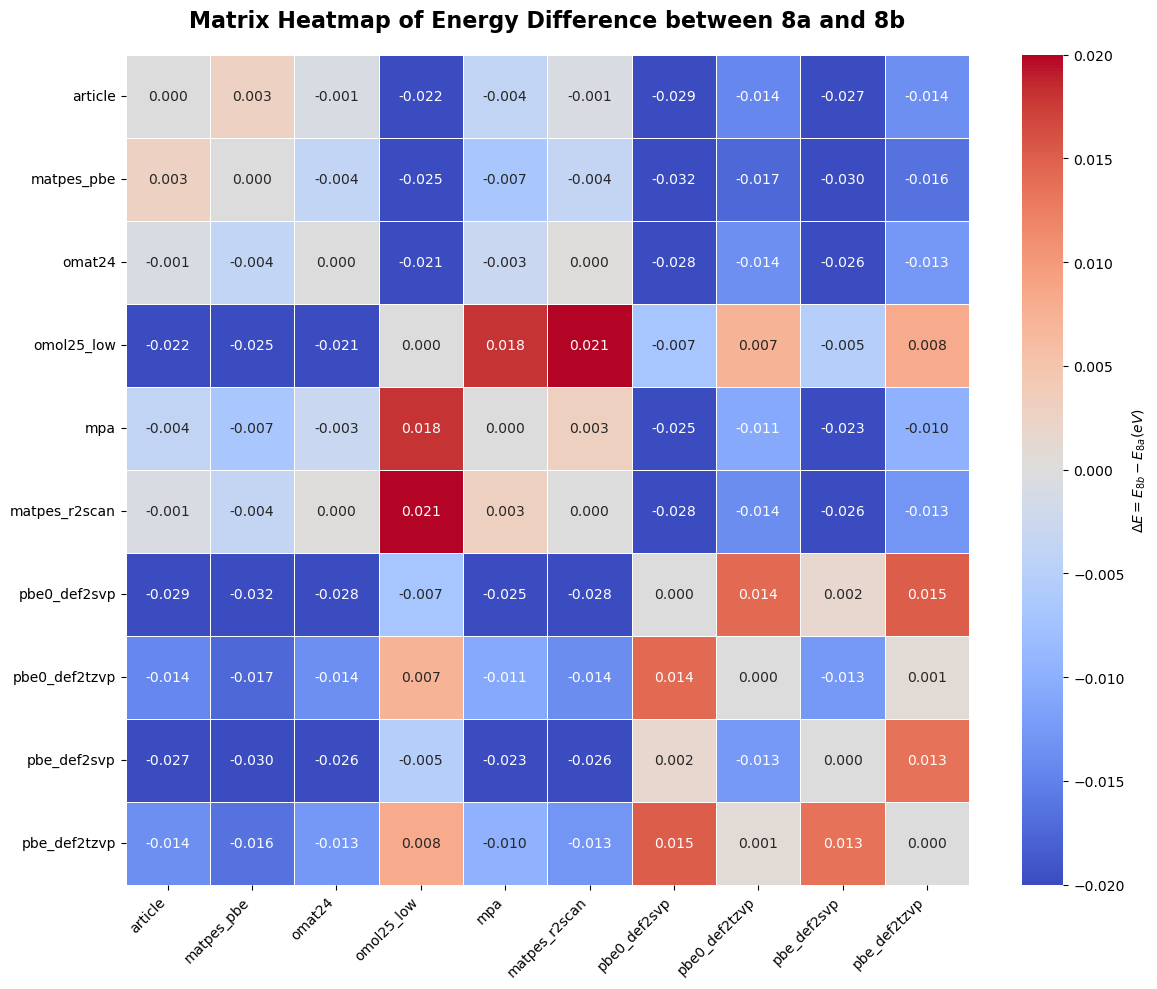

In [27]:
# 1. Load the dataset, using the first column (method names) as the row index
df = pd.read_csv(general_save / "ddE_8ab_self_matrix.csv", index_col=0)

# 2. Initialize the plot and set the figure size using subplots
fig, ax = plt.subplots(figsize=(12, 10))

# 3. Create the heatmap
# - annot=True displays the data values in each cell
# - fmt=".3f" formats the displayed numbers to 3 decimal places
# - cmap="viridis" applies a color map ranging from low to high values
# - linewidths adds a subtle boundary between cells for better clarity
sns.heatmap(df, annot=True, fmt=".3f", cmap="coolwarm", ax=ax, vmin=-0.02, vmax=0.02, cbar_kws={'label': r"$\Delta E = E_{8b} - E_{8a} (eV) $"}, linewidths=.5)

# 4. Customize labels and titles for readability
ax.set_title("Matrix Heatmap of Energy Difference between 8a and 8b", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels to prevent overlap
plt.yticks(rotation=0)                # Keep y-axis labels horizontal

# 5. Automatically adjust layout elements so nothing gets truncated
plt.tight_layout()

# 6. Save the resulting figure
path_ = to_path("~/organized/901_data/ddE_8ab_self_hm.pdf")
plt.savefig(path_)
plt.show()

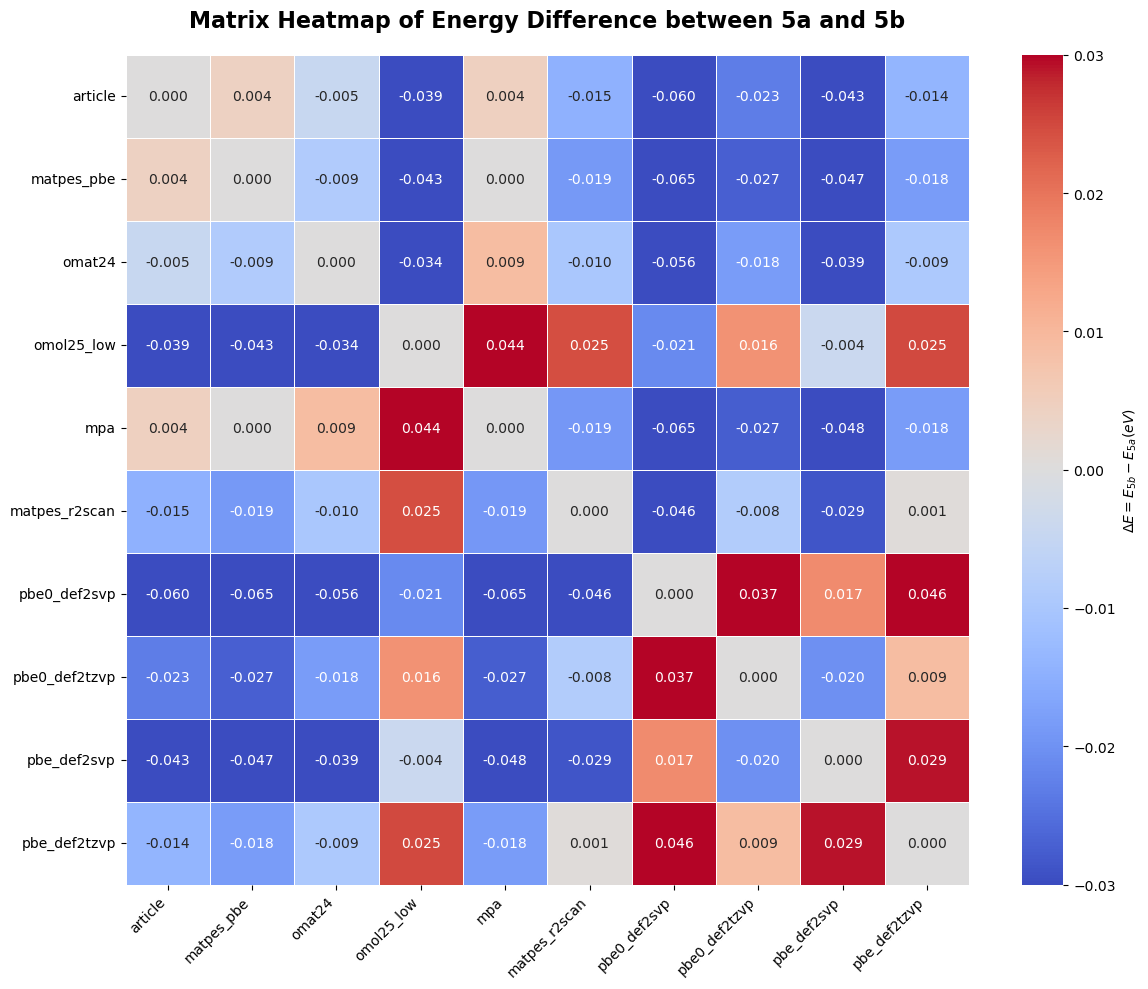

In [25]:
# 1. Load the dataset, using the first column (method names) as the row index
df = pd.read_csv(general_save / "ddE_5ab_self_matrix.csv", index_col=0)

# 2. Initialize the plot and set the figure size using subplots
fig, ax = plt.subplots(figsize=(12, 10))

# 3. Create the heatmap
# - annot=True displays the data values in each cell
# - fmt=".3f" formats the displayed numbers to 3 decimal places
# - cmap="viridis" applies a color map ranging from low to high values
# - linewidths adds a subtle boundary between cells for better clarity
sns.heatmap(df, annot=True, fmt=".3f", cmap="coolwarm", ax=ax, vmin=-0.03, vmax=0.03, cbar_kws={'label': r"$\Delta E = E_{5b} - E_{5a} (eV) $"}, linewidths=.5)

# 4. Customize labels and titles for readability
ax.set_title("Matrix Heatmap of Energy Difference between 5a and 5b", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels to prevent overlap
plt.yticks(rotation=0)                # Keep y-axis labels horizontal

# 5. Automatically adjust layout elements so nothing gets truncated
plt.tight_layout()

# 6. Save the resulting figure
path_ = to_path("~/organized/901_data/ddE_5ab_self_hm.pdf")
plt.savefig(path_)
plt.show()
